## Problem 10.2 - Classification Tree and Comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

In [36]:
# generate data and split into train and test set
X, y = make_blobs(n_samples = 300, centers = 3, n_features = 2, cluster_std = 1.5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

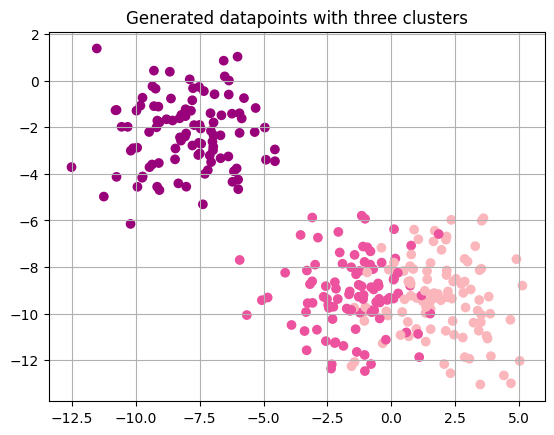

In [37]:
# plot the genrated data points
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = truncated_RdPu)
plt.title("Generated datapoints with three clusters")
plt.grid()

In [38]:
criterions = ["gini", "entropy", "log_loss"]
alphas = np.linspace(0.0, 0.15, 100)

In [39]:
# find the best pruning parameter alpha for each criterion
best_alpha = {}
best_score = {}

for criterion in criterions:
    alpha_scores = []

    for alpha in alphas:
        classifier = DecisionTreeClassifier(criterion = criterion, ccp_alpha = alpha, random_state = 42)
        cv_scores = cross_val_score(classifier, X_train, y_train, cv = 10, scoring = 'accuracy')
        mean_score = np.mean(cv_scores)
        alpha_scores.append(mean_score)
    
    best_index = np.argmax(alpha_scores)
    best_alpha[criterion] = alphas[best_index]
    best_score[criterion] = alpha_scores[best_index]

    print(f"Best alpha for {criterion}: {best_alpha[criterion]:.4f} (CV accuracy = {best_score[criterion]:.4f})")

Best alpha for gini: 0.0152 (CV accuracy = 0.9000)
Best alpha for entropy: 0.0106 (CV accuracy = 0.9000)
Best alpha for log_loss: 0.0106 (CV accuracy = 0.9000)


In [40]:
# get gini-optimal alpha
gini_opt_alpha = best_alpha["gini"]

In [41]:
# Train decision tree classifier for the gini optimal alpha
dec_tree = DecisionTreeClassifier(criterion = 'gini', ccp_alpha = gini_opt_alpha, random_state = 42)
dec_tree.fit(X_train, y_train)
accuracy_tree = dec_tree.score(X_test, y_test)
train_accuracy_tree = dec_tree.score(X_train, y_train)
print(f"Decicion Tree Test Accuracy for alpha = {gini_opt_alpha:.4f}: {accuracy_tree:.4f}" )
print(f"Decicion Tree Train Accuracy for alpha = {gini_opt_alpha:.4f}: {train_accuracy_tree:.4f}" )


Decicion Tree Test Accuracy for alpha = 0.0152: 0.9167
Decicion Tree Train Accuracy for alpha = 0.0152: 0.9208


In [42]:
# train classifiers svm, logistic regression and knn
svm = SVC(kernel = 'rbf', random_state = 42)
svm.fit(X_train, y_train)
accuracy_svm = svm.score(X_test, y_test)
train_accuracy_svm = svm.score(X_train, y_train)

logreg = LogisticRegression(max_iter = 2000, random_state = 42)
logreg.fit(X_train, y_train)
accuracy_logreg = logreg.score(X_test, y_test)
train_accuracy_logreg = logreg.score(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
accuracy_knn = knn.score(X_test, y_test)
train_accuracy_knn = knn.score(X_train, y_train)

In [43]:
def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
    y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha = 0.25, cmap = truncated_RdPu)

    ax.scatter(X_train[:,0], X_train[:,1], c = y_train, marker = 'o', edgecolor = 'k', s = 40, label = 'train', cmap = truncated_RdPu)
    ax.scatter(X_test[:,0], X_test[:,1], c = y_test, marker = 's', edgecolor = 'k', s = 60, label = 'test', cmap = truncated_RdPu)
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc = 'upper right', fontsize = 'small')

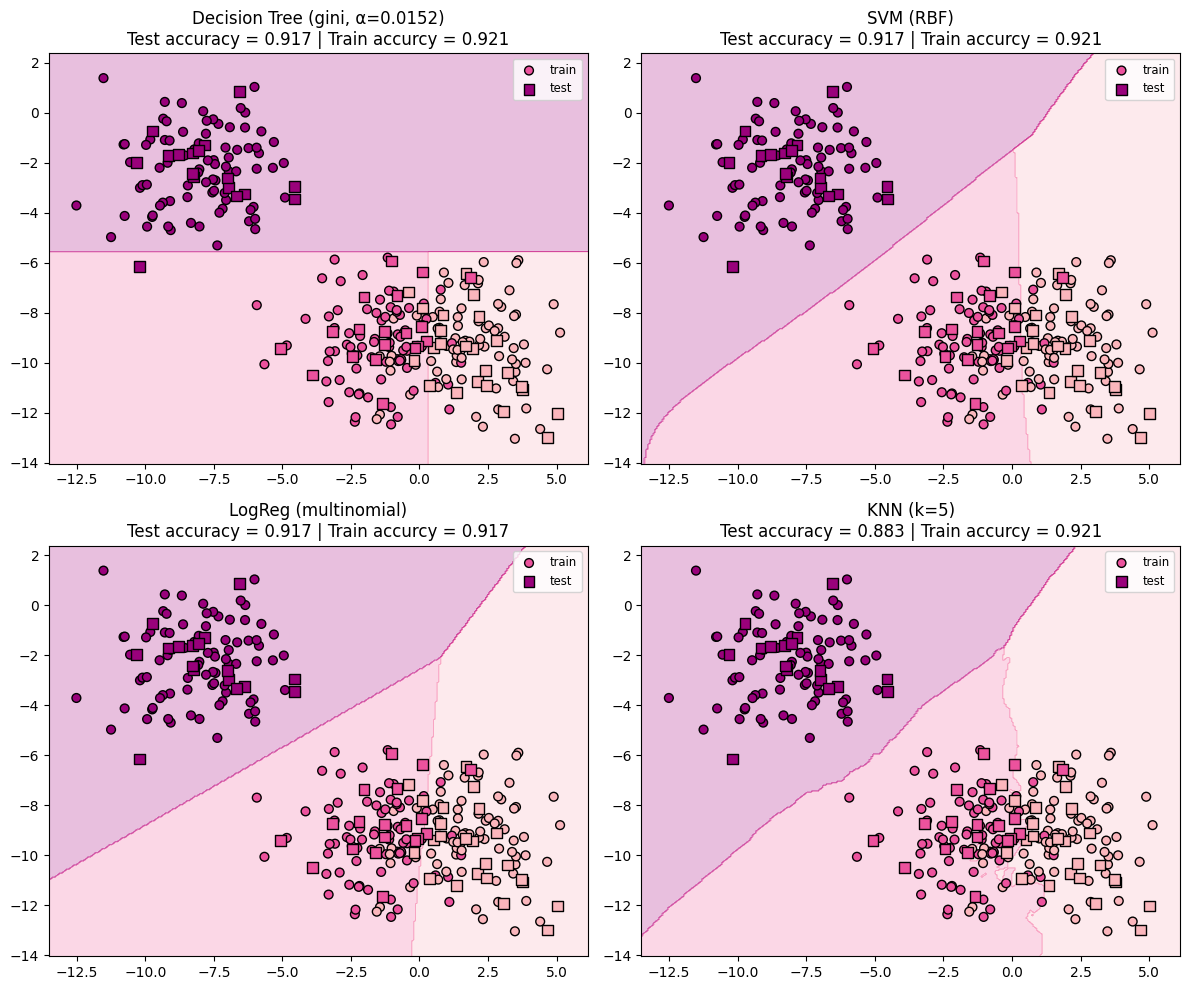

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()
plot_decision_boundary(axes[0], dec_tree, X, y, title = f"Decision Tree (gini, α={gini_opt_alpha:.4f})\nTest accuracy = {accuracy_tree:.3f} | Train accurcy = {train_accuracy_tree:.3f}")
plot_decision_boundary(axes[1], svm, X, y, title = f"SVM (RBF)\nTest accuracy = {accuracy_svm:.3f} | Train accurcy = {train_accuracy_svm:.3f}")
plot_decision_boundary(axes[2], logreg, X, y, title = f"LogReg (multinomial)\nTest accuracy = {accuracy_logreg:.3f} | Train accurcy = {train_accuracy_logreg:.3f}")
plot_decision_boundary(axes[3], knn, X, y, title = f"KNN (k=5)\nTest accuracy = {accuracy_knn:.3f} | Train accurcy = {train_accuracy_knn:.3f}")
plt.tight_layout()
plt.show()